# 19 · Project: staffing a call centre from data

A service line must answer 80 % of calls within 20 seconds, every half hour of the day, with as few agents as
possible. The data are 20 weekdays of logged calls (`call_centre.csv`): arrival times and handle times, with an
outage and some dropped connections. The project combines the course: estimate a non-homogeneous arrival
rate (notebook 09), model the service times (01, 12), staff each half hour by Erlang C (12), test the
schedule in a discrete-event simulation with impatient callers and a rate that changes through the day (13),
analyse the output honestly (14), test the stationary model and its textbook correction, and report.

**What you will learn**
- estimate a time-varying arrival rate from logs and decide what to do with faulty data
- choose between closed-form models and simulation for a decision
- test a standard method and its textbook correction against simulation
- optimise by simulation and assess the result on fresh random numbers

**Before you start:** the whole course  ·  **Time:** about 4 h

In [1]:
try:                      # on Google Colab (or anywhere engstoch is missing): install it from GitHub
    import engstoch
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engstoch"], check=True)
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from engstoch import poisson as pp, queues as qu, des, montecarlo as mc, models, datasets
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")

R = np.random.default_rng      # R(seed): a fresh, reproducible generator

## 1. The data and their faults

In [2]:
cc = pd.read_csv(datasets.path("call_centre.csv"), comment="#")
print(f"{len(cc)} calls over {cc.day.nunique()} days; zero handle times: {(cc.handle_min == 0).sum()}")
cnt = cc.groupby("day").size()
hh = cc.assign(slot=(cc.arrival_h * 2).astype(int) / 2).groupby(["day", "slot"]).size().unstack(fill_value=0)
print("days with empty half hours during opening:", {d: [float(s) for s in hh.columns[(hh.loc[d] == 0).to_numpy()]] for d in hh.index if (hh.loc[d] == 0).any()})
calls = cc[cc.handle_min > 0].copy()
outage = (calls.day == 8) & (calls.arrival_h >= 13.0) & (calls.arrival_h < 14.5)
print("weekday means:", cnt.groupby(cc.groupby("day").weekday.first()).mean().round(0).to_dict())

22182 calls over 20 days; zero handle times: 82
days with empty half hours during opening: {8: [13.0, 13.5, 14.0]}
weekday means: {'Fri': 1084.0, 'Mon': 1231.0, 'Thu': 1087.0, 'Tue': 1082.0, 'Wed': 1061.0}


Two faults need decisions before any modelling. Day 8 has three empty half hours in the early afternoon - a
logging outage, not an absence of demand - so those slots are excluded from day 8 (the day's other slots are
kept). Zero handle times are dropped connections: they are not service and are removed from the handle-time
data (they are 0.4 % of calls, so whether they still count as arrivals hardly matters). Mondays are busier and
are planned separately; the rest of this project staffs a Tuesday-Friday day.

## 2. The arrival rate

per-slot dispersion tests across the 16 days: smallest p = 0.082; fraction below 0.05 = 0.00


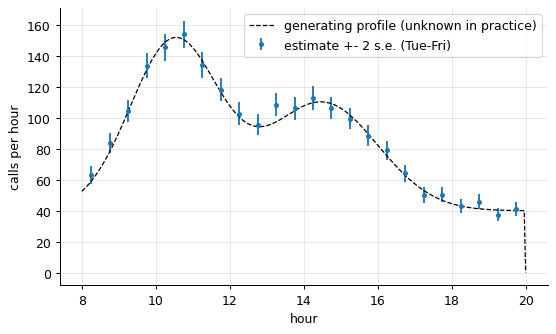

In [3]:
edges = np.arange(8.0, 20.01, 0.5)
mid = edges[:-1] + 0.25
week = calls[(calls.weekday != "Mon")]
counts = []
for d, g in week.groupby("day"):
    c = pp.counts_in_windows(g.arrival_h.to_numpy(), edges).astype(float)
    if d == 8:
        c[(edges[:-1] >= 13.0) & (edges[:-1] < 14.5)] = np.nan
    counts.append(c)
counts = np.array(counts)
n_days = np.sum(~np.isnan(counts), axis=0)
lam_hat = np.nansum(counts, axis=0) / n_days / 0.5
se = np.sqrt(np.nansum(counts, axis=0)) / n_days / 0.5
disp = [pp.dispersion_test(counts[~np.isnan(counts[:, j]), j])["p_value"] for j in range(len(mid))]
print(f"per-slot dispersion tests across the {counts.shape[0]} days: smallest p = {min(disp):.3f}; fraction below 0.05 = {np.mean(np.array(disp) < 0.05):.2f}")
plt.errorbar(mid, lam_hat, 2 * se, fmt="o", ms=3, label="estimate +- 2 s.e. (Tue-Fri)"); plt.plot(np.linspace(8, 20, 300), models.call_centre_rate(np.linspace(8, 20, 300)), "k--", lw=1, label="generating profile (unknown in practice)")
plt.xlabel("hour"); plt.ylabel("calls per hour"); plt.legend(); plt.show()

Averaging the counts of each half hour over the 16 Tuesday-Friday days gives the rate profile with Poisson
standard errors of 5-8 %; the counts of a slot vary between days no more than Poisson variation allows (the
dispersion tests are unremarkable), so a non-homogeneous Poisson process with this profile is a reasonable
model. The peak at 10:30 is three and a half times the evening rate.

## 3. Service times

In [4]:
h = calls.handle_min.to_numpy()
ln_mu, ln_sd = np.log(h).mean(), np.log(h).std(ddof=1)
print(f"handle times: mean {h.mean():.3f} min, sd {h.std():.3f}, cv {h.std() / h.mean():.3f}")
print(f"lognormal fit: KS p = {stats.kstest(np.log(h), 'norm', args=(ln_mu, ln_sd)).pvalue:.3f};  exponential fit: KS p = {stats.kstest(h, 'expon', args=(0, h.mean())).pvalue:.1e}")
by_hour = calls.assign(hour=calls.arrival_h.astype(int)).groupby("hour").handle_min.mean()
print("mean handle time by hour of arrival:", by_hour.round(2).to_dict())
mean_h = h.mean() / 60                                  # hours

handle times: mean 3.961 min, sd 3.113, cv 0.786
lognormal fit: KS p = 0.558;  exponential fit: KS p = 0.0e+00
mean handle time by hour of arrival: {8: 3.9, 9: 4.01, 10: 3.92, 11: 4.0, 12: 4.01, 13: 4.02, 14: 3.98, 15: 3.91, 16: 3.96, 17: 4.06, 18: 3.78, 19: 3.85}


Handle times are lognormal with mean 4 minutes and cv 0.8, not exponential, and do not drift through the day.
Erlang C assumes exponential service; with cv < 1 it should be slightly pessimistic (notebook 12) - but the
bigger question is whether a *stationary* model can describe a half hour in which the rate changes.

## 4. A first schedule: Erlang C slot by slot

In [5]:
target, answer = 0.8, 20 / 3600
c_sipp = np.array([qu.staffing(l, 1 / mean_h, target, answer)["c"] for l in lam_hat])
print("agents per half hour (stationary independent period-by-period, 'SIPP'):", c_sipp.tolist())
print(f"agent-hours per day: {0.5 * c_sipp.sum():.1f}")
def agents_fn(schedule):
    return lambda t: int(schedule[min(max(int((t - 8.0) / 0.5), 0), len(schedule) - 1)])
rate_fn = lambda t: float(np.interp(t, mid, lam_hat, left=0, right=0)) if 8.0 <= t < 20.0 else 0.0
rate_max = 1.05 * lam_hat.max()

agents per half hour (stationary independent period-by-period, 'SIPP'): [7, 9, 10, 12, 13, 14, 12, 11, 10, 9, 10, 10, 11, 10, 10, 9, 8, 7, 6, 6, 5, 6, 5, 5]
agent-hours per day: 107.5


Each half hour is treated as a stationary M/M/c queue with its own arrival rate and staffed with the smallest c
that meets the target - the usual practice. The rate function used in the simulation interpolates the
half-hourly estimates linearly, which is closer to how demand really moves than a step function.

## 5. Testing the schedule by simulation

SIPP schedule, 40 simulated days: daily service level 0.893 +- 0.005, abandonment 0.029
half hours significantly below 80 %: []


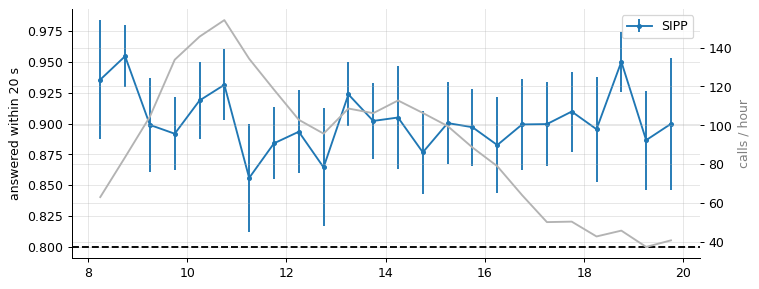

In [6]:
def run_day(schedule, seed, patience=True):
    r = des.call_centre(rate_fn, rate_max, lambda g: float(np.exp(ln_mu + ln_sd * g.standard_normal())) / 60, agents_fn(schedule), 21.0, R(seed),
                        patience_sampler=(lambda g: g.exponential(3.0 / 60)) if patience else None, answer_within=answer)
    slot = np.clip(((r["arrival"] - 8.0) / 0.5).astype(int), 0, len(mid) - 1)
    ok = (~r["abandoned"]) & (np.nan_to_num(r["wait"], nan=1.0) <= answer)
    sl = np.array([ok[slot == j].mean() if np.any(slot == j) else np.nan for j in range(len(mid))])
    ab = np.array([r["abandoned"][slot == j].mean() if np.any(slot == j) else np.nan for j in range(len(mid))])
    return sl, ab, ok.mean(), r["abandoned"].mean()
def evaluate(schedule, reps=40, seed0=0):
    out = [run_day(schedule, seed0 + k) for k in range(reps)]
    sl = np.array([o[0] for o in out]); ab = np.array([o[1] for o in out])
    day = mc.mean_ci([o[2] for o in out], method="t")
    return {"slot_sl": np.nanmean(sl, axis=0), "slot_se": np.nanstd(sl, axis=0, ddof=1) / np.sqrt(reps), "slot_ab": np.nanmean(ab, axis=0), "day_sl": day, "day_ab": float(np.mean([o[3] for o in out]))}
ev_sipp = evaluate(c_sipp)
print(f"SIPP schedule, 40 simulated days: daily service level {ev_sipp['day_sl']['estimate']:.3f} +- {ev_sipp['day_sl']['std_error']:.3f}, abandonment {ev_sipp['day_ab']:.3f}")
miss = mid[ev_sipp["slot_sl"] + 2 * ev_sipp["slot_se"] < target]
print("half hours significantly below 80 %:", miss.tolist())
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.errorbar(mid, ev_sipp["slot_sl"], 2 * ev_sipp["slot_se"], fmt="o-", ms=3, label="SIPP"); ax.axhline(target, color="k", ls="--"); ax.set_ylabel("answered within 20 s")
ax2 = ax.twinx(); ax2.plot(mid, lam_hat, color="0.7"); ax2.set_ylabel("calls / hour", color="0.5"); ax.legend(); plt.show()

Forty simulated days with lognormal handle times, 3-minute mean patience and a continuously varying rate give
the service level of every half hour with an interval. The literature warns that SIPP fails on a ramp: the rate
rises *within* the half hour and work arriving late in one slot spills into the next. Here no slot misses -
Erlang C's pessimism (exponential service where the real cv is 0.8, and no abandonment where 3 % of callers
leave) more than pays for the lag. The schedule meets the target with room to spare in most slots, which
suggests it is too expensive rather than too thin.

## 6. Accounting for the lag: the offered-load (infinite-server) approximation

In [7]:
tgrid = np.linspace(8.0, 20.0, 2401)
lam_t = np.array([rate_fn(t) for t in tgrid])
dt = tgrid[1] - tgrid[0]
s_grid = np.arange(0, 2.0, dt)
surv = stats.lognorm.sf(s_grid * 60, ln_sd, scale=np.exp(ln_mu))      # P(S > s), s in hours
load = np.convolve(lam_t, surv)[: len(tgrid)] * dt                     # m(t) = int lambda(t - s) P(S > s) ds  (M_t/G/inf mean)
c_lag = []
for j, t0 in enumerate(edges[:-1]):
    w = (tgrid >= t0) & (tgrid < t0 + 0.5)
    a_eff = np.max(load[w])                                           # staff for the busiest moment of the slot
    c_lag.append(qu.staffing(a_eff / mean_h, 1 / mean_h, target, answer)["c"])
c_lag = np.array(c_lag)
print("lag-aware schedule:", c_lag.tolist(), f"\nagent-hours {0.5 * c_lag.sum():.1f} (SIPP {0.5 * c_sipp.sum():.1f})")
ev_lag = evaluate(c_lag, seed0=1000)
print(f"lag-aware schedule: daily service level {ev_lag['day_sl']['estimate']:.3f} +- {ev_lag['day_sl']['std_error']:.3f}; half hours significantly below 80 %:", mid[ev_lag["slot_sl"] + 2 * ev_lag["slot_se"] < target].tolist())

lag-aware schedule: [8, 9, 11, 13, 14, 14, 14, 12, 11, 10, 11, 11, 11, 11, 10, 10, 9, 8, 7, 6, 6, 6, 5, 5] 
agent-hours 116.0 (SIPP 107.5)


lag-aware schedule: daily service level 0.947 +- 0.002; half hours significantly below 80 %: []


The number of calls *in progress* in an infinite-server system with time-varying arrivals is
m(t) = ∫ λ(t − s) P(S > s) ds - the arrival rate smoothed and delayed by the service-time distribution
(Eick, Massey and Whitt). Staffing each slot for its peak offered load m(t) builds in both the within-slot rise
and the spill-over. It is the safe textbook remedy - and here it buys a service level of 95 % for eight extra
agent-hours that the target does not require. Both stationary schedules are starting points; the simulation
has to decide how many agents are really needed.

## 7. Trimming: the cheapest schedule that meets the target everywhere

trimmed schedule: [7, 8, 10, 12, 13, 13, 13, 11, 10, 9, 10, 10, 10, 10, 9, 9, 8, 7, 6, 5, 5, 5, 4, 4] 
agent-hours 104.0


final check on 80 fresh days: service level 0.879 +- 0.003, worst half hour 0.801, abandonment 0.035


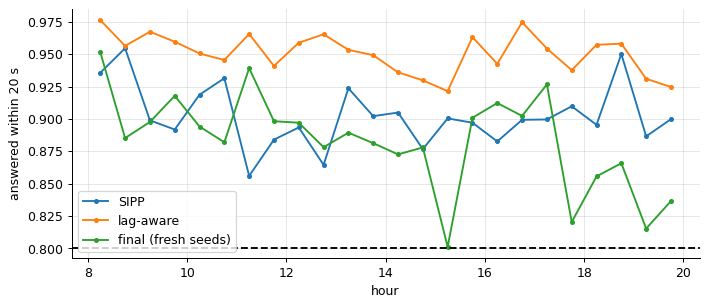

In [8]:
sched = c_lag.copy()
ev = ev_lag
for it in range(3):
    slack = ev["slot_sl"] - 2 * ev["slot_se"] - target
    trial = sched.copy()
    trial[(slack > 0.06) & (sched > 1)] -= 1                           # remove an agent where the margin is large
    ev_t = evaluate(trial, seed0=2000 + 100 * it)
    if np.all(ev_t["slot_sl"] + 2 * ev_t["slot_se"] >= target):
        sched, ev = trial, ev_t
print("trimmed schedule:", sched.tolist(), f"\nagent-hours {0.5 * sched.sum():.1f}")
final = evaluate(sched, reps=80, seed0=9000)                           # fresh seeds for the final assessment
print(f"final check on 80 fresh days: service level {final['day_sl']['estimate']:.3f} +- {final['day_sl']['std_error']:.3f}, worst half hour {np.min(final['slot_sl']):.3f}, abandonment {final['day_ab']:.3f}")
fig, ax = plt.subplots(figsize=(9, 3.6))
for name, e in (("SIPP", ev_sipp), ("lag-aware", ev_lag), ("final (fresh seeds)", final)):
    ax.plot(mid, e["slot_sl"], "o-", ms=3, label=name)
ax.axhline(target, color="k", ls="--"); ax.legend(); ax.set_xlabel("hour"); ax.set_ylabel("answered within 20 s"); plt.show()

Removing agents only where the simulated margin is large, and accepting a change only if every half hour still
meets the target, gives a schedule cheaper than both stationary ones - a few agent-hours below SIPP - with its
worst half hour right at the target. Because the trimming used the
simulation to *choose*, the final schedule is re-evaluated on fresh random numbers - the honest estimate of
its performance (notebook 13's winner's curse).

## 8. The report

In [9]:
report = f'''# Staffing a service line: from call logs to a half-hourly schedule

Data: 20 weekdays, {len(cc)} calls. Removed: {int((cc.handle_min == 0).sum())} zero-length (dropped) calls from the handle-time data;
      day 8 13:00-14:30 excluded from the rate estimate (logging outage). Mondays (+{100 * (cnt[cc.groupby('day').weekday.first() == 'Mon'].mean() / cnt[cc.groupby('day').weekday.first() != 'Mon'].drop(8).mean() - 1):.0f} %) need their own schedule.
Arrivals: non-homogeneous Poisson, half-hourly rates {lam_hat.min():.0f}-{lam_hat.max():.0f} calls/h (s.e. 5-8 %); counts consistent with Poisson variation.
Service: lognormal, mean {h.mean():.2f} min, cv {h.std() / h.mean():.2f}; no trend through the day. Patience assumed exponential, mean 3 min (not in the data).
Target: 80 % answered within 20 s in every half hour.
SIPP (Erlang C per slot): {0.5 * c_sipp.sum():.1f} agent-hours; day {ev_sipp['day_sl']['estimate']:.3f}, {len(miss)} half hours significantly below target (Erlang C's pessimism covers the ramp).
Lag-aware (peak offered load of the M_t/G/inf model per slot): {0.5 * c_lag.sum():.1f} agent-hours; day {ev_lag['day_sl']['estimate']:.3f} - safe but more than needed.
Recommended (lag-aware, trimmed by simulation): {0.5 * sched.sum():.1f} agent-hours; on 80 fresh simulated days the daily service level is
      {final['day_sl']['estimate']:.3f} +- {final['day_sl']['std_error']:.3f}, worst half hour {np.min(final['slot_sl']):.3f}, abandonment {100 * final['day_ab']:.1f} %.
Schedule (agents per half hour from 08:00): {sched.tolist()}
Caveats: the patience distribution is assumed; shift constraints (agents work blocks, not half hours) are not modelled; the rate estimate has
      5-8 % error per slot, so the schedule should be re-checked against a rate 10 % higher in the peak (a one-line change above).
'''
print(report)

# Staffing a service line: from call logs to a half-hourly schedule

Data: 20 weekdays, 22182 calls. Removed: 82 zero-length (dropped) calls from the handle-time data;
      day 8 13:00-14:30 excluded from the rate estimate (logging outage). Mondays (+13 %) need their own schedule.
Arrivals: non-homogeneous Poisson, half-hourly rates 38-154 calls/h (s.e. 5-8 %); counts consistent with Poisson variation.
Service: lognormal, mean 3.96 min, cv 0.79; no trend through the day. Patience assumed exponential, mean 3 min (not in the data).
Target: 80 % answered within 20 s in every half hour.
SIPP (Erlang C per slot): 107.5 agent-hours; day 0.893, 0 half hours significantly below target (Erlang C's pessimism covers the ramp).
Lag-aware (peak offered load of the M_t/G/inf model per slot): 116.0 agent-hours; day 0.947 - safe but more than needed.
Recommended (lag-aware, trimmed by simulation): 104.0 agent-hours; on 80 fresh simulated days the daily service level is
      0.879 +- 0.003, worst hal

The report follows the course's method: clean the data on documented grounds, model what the data support
(Poisson arrivals with a daily profile, lognormal service) and state what they do not (patience), use the
closed-form theory where it applies and simulation where it does not, put intervals on every simulated
number, test the standard practice and its textbook correction instead of assuming either, and assess the final
choice on fresh random numbers. Its central finding - that both stationary rules over-staff this line and a
simulation-trimmed schedule saves agent-hours - came from the simulation, not from a rule.

## Inside the analysis: the morning ramp in numbers

In [10]:
j = int(np.argmax(np.diff(lam_hat)))
print(f"steepest rise between {mid[j]:.2f} and {mid[j + 1]:.2f} h: {lam_hat[j]:.0f} -> {lam_hat[j + 1]:.0f} calls/h")
for jj in (j, j + 1):
    w_ = (tgrid >= edges[jj]) & (tgrid < edges[jj] + 0.5)
    print(f"slot {edges[jj]:.1f}: mean arrival rate x mean handle = {lam_hat[jj] * mean_h:.1f} erlangs; peak offered load m(t) = {load[w_].max():.1f}; SIPP {c_sipp[jj]}, lag-aware {c_lag[jj]}")

steepest rise between 9.25 and 9.75 h: 104 -> 134 calls/h
slot 9.0: mean arrival rate x mean handle = 6.9 erlangs; peak offered load m(t) = 7.9; SIPP 10, lag-aware 11
slot 9.5: mean arrival rate x mean handle = 8.8 erlangs; peak offered load m(t) = 9.5; SIPP 12, lag-aware 13


## Exercises
1. Build the Monday schedule from the Monday data alone (four days) and from the Tuesday-Friday profile scaled by the estimated Monday factor. Which is more reliable, and how do they compare in simulation?
2. Patience is not in the data. Repeat the final assessment with mean patience 1, 3 and 10 minutes and with deterministic patience. How sensitive is the recommendation?
3. **Implement it yourself:** add shift constraints - agents work 4-hour blocks starting on the hour - and find the cheapest set of shifts whose half-hourly coverage is at least the recommended schedule (a small integer program; brute force or a greedy heuristic), then assess it by simulation.